In [1]:
!wget -O "Plant Disease.zip" "https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded"

--2026-08-06 08:49:48--  https://data.mendeley.com/public-files/datasets/tywbtsjrjv/files/b4e3a32f-c0bd-4060-81e9-6144231f2520/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.133.86, 162.159.130.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.133.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd [following]
--2026-08-06 08:49:48--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/349ac012-2948-4172-bbba-3bf8f76596fd
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.73.59, 3.5.70.192, 3.5.75.30, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.73.59|:443... connect

In [2]:
!unzip "/content/Plant Disease.zip"

Streaming output truncated to the last 5000 lines.
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (132).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1320).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1321).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1322).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1323).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1324).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1325).JPG  
  inflating: Plant_leave_diseases_dataset_with_augmentation/Tomato___Tomato_Yellow_Leaf_Curl_Virus/image (1326).JPG  
  infl

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

In [5]:
!pip install split-folders

In [6]:
import splitfolders
splitfolders.ratio("/content/Plant_leave_diseases_dataset_with_augmentation",output="dataset", seed =1337,ratio=(0.8,0.1,0.1))

Copying files: 61486 files [00:14, 4187.69 files/s]



### Data Preprocessing

In [7]:
train_dir = "/content/dataset/train"
validation_dir= "/content/dataset/val"
test_dir = "/content/dataset/test"
BATCH_SIZE = 32
IMG_SIZE = (160,160)

train_dataset = tf.keras.utils.image_dataset_from_directory(train_dir,shuffle=True,batch_size=BATCH_SIZE,image_size=IMG_SIZE)
validation_dataset = tf.keras.utils.image_dataset_from_directory(validation_dir,shuffle=True,batch_size=BATCH_SIZE,image_size=IMG_SIZE)
test_dataset = tf.keras.utils.image_dataset_from_directory(test_dir,shuffle=True,batch_size=BATCH_SIZE,image_size=IMG_SIZE)

Found 49179 files belonging to 39 classes.
Found 6139 files belonging to 39 classes.
Found 6168 files belonging to 39 classes.


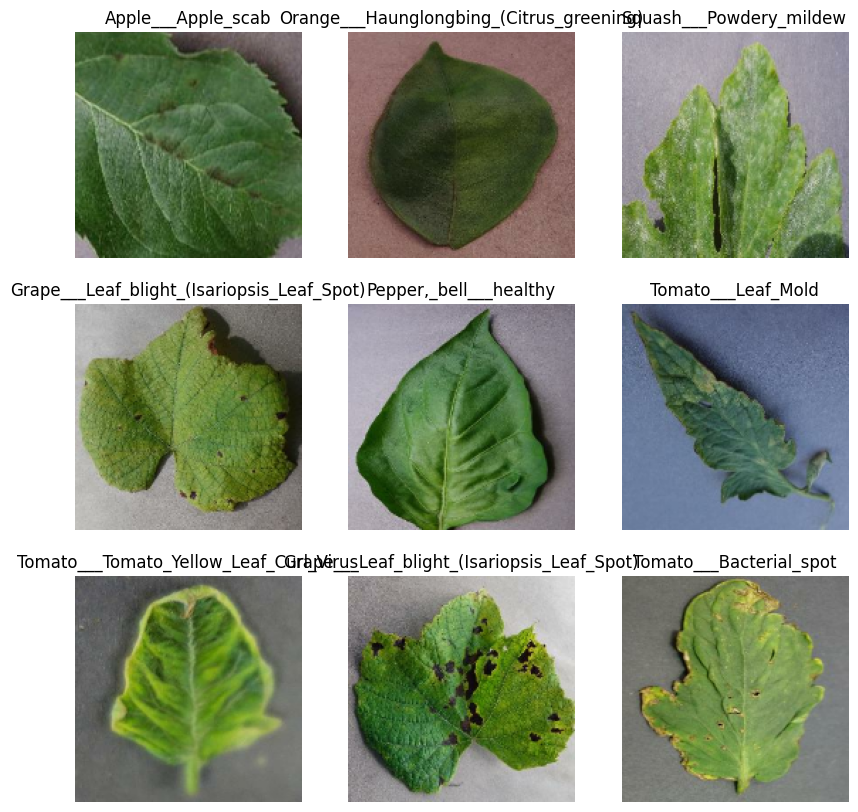

In [8]:
class_names = train_dataset.class_names
plt.figure(figsize=(10,10))
for images,labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [16]:
class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Background_without_leaves',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot'

In [9]:
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

### Create the base model from the pre-trained convnets

In [10]:
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.EfficientNetB4(input_shape=IMG_SHAPE,include_top=False,weights="imagenet")

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [11]:
image_batch, label_batch= next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1792)


### Feature Extraction

In [12]:
# freezing the base model
base_model.trainable = False
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)
prediction_layer = tf.keras.layers.Dense(len(class_names),activation="softmax")
prediction_batch = prediction_layer(feature_batch_average)
print(prediction_batch.shape)
#

(32, 1792)
(32, 39)


In [18]:
inputs = tf.keras.Input(shape=(160, 160, 3))
#preprocess raw inputs
x = preprocess_input(inputs)
#pass inputs through frozen base model
x = base_model(x, training=False)
#global average pooling to reduce dimension
x = global_average_layer(x)
#dropout for regularization
x = tf.keras.layers.Dropout(0.2)(x)
#final dense classification layer
outputs = prediction_layer(x)
#combine into a final functional modelwhat global average pooling do?
model = tf.keras.Model(inputs, outputs)

In [20]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [21]:
initial_epochs =6
loss0,accuracy0 = model.evaluate(validation_dataset) #intial baseline loss-loss
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

192/192 ━━━━━━━━━━━━━━━━━━━━ 53s 146ms/step - accuracy: 0.0349 - loss: 3.7371
initial loss: 3.74
initial accuracy: 0.03


In [22]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset) #save all training objects

Epoch 1/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 168s 79ms/step - accuracy: 0.8184 - loss: 0.7122 - val_accuracy: 0.9099 - val_loss: 0.3249
Epoch 2/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 97s 63ms/step - accuracy: 0.9081 - loss: 0.3184 - val_accuracy: 0.9303 - val_loss: 0.2334
Epoch 3/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 100s 65ms/step - accuracy: 0.9243 - loss: 0.2545 - val_accuracy: 0.9401 - val_loss: 0.1985
Epoch 4/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 108s 70ms/step - accuracy: 0.9324 - loss: 0.2198 - val_accuracy: 0.9446 - val_loss: 0.1734
Epoch 5/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 131s 63ms/step - accuracy: 0.9367 - loss: 0.2020 - val_accuracy: 0.9458 - val_loss: 0.1650
Epoch 6/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 141s 63ms/step - accuracy: 0.9420 - loss: 0.1875 - val_accuracy: 0.9547 - val_loss: 0.1475


In [24]:
loss,accuracy = model.evaluate(validation_dataset) #average loss calculated during training
print("training loss: {:.2f}".format(loss))
print("training accuracy: {:.2f}".format(accuracy))

192/192 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.9547 - loss: 0.1475
training loss: 0.15
training accuracy: 0.95


### Learning Curves

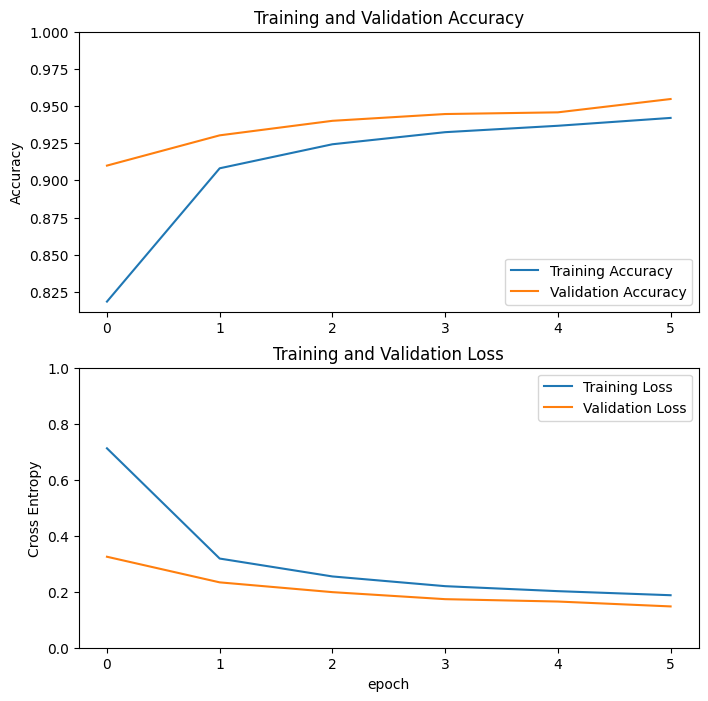

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

**NOTE:** Training vs Fine Tuning
training starts with random weights initialization and goal is to teach network basic features

fine tuning takes model that has already trained on massive general dataset.start on pretrained weights already understand basic features

### Fine Tuning

In [26]:
base_model.trainable = True # why unfreeze base model - eary layers extract fundamental visual elements common to lmost any image

In [35]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer .first 100 layers, keeping their pre-trained
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  475


In [36]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')])

In [46]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 5, 5, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 39)             │        69,927 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,807,318 (201.44 MB)

 Trainable params: 17,531,783 (66.88 MB)

 Non-trainable params: 211,967 (828.00 KB)

 Optimizer params: 35,063,568 (133.76 MB)

In [37]:
fine_tune_epochs = 6


In [39]:
history_fine = model.fit(train_dataset,
                         epochs=fine_tune_epochs,
                         validation_data=validation_dataset)

Epoch 1/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 468s 221ms/step - accuracy: 0.9410 - loss: 0.2065 - val_accuracy: 0.9687 - val_loss: 0.2258
Epoch 2/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 250s 163ms/step - accuracy: 0.9729 - loss: 0.0906 - val_accuracy: 0.9329 - val_loss: 1.2551
Epoch 3/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 248s 162ms/step - accuracy: 0.9786 - loss: 0.0685 - val_accuracy: 0.9782 - val_loss: 0.0786
Epoch 4/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 258s 168ms/step - accuracy: 0.9815 - loss: 0.0599 - val_accuracy: 0.9814 - val_loss: 0.0679
Epoch 5/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 258s 168ms/step - accuracy: 0.9834 - loss: 0.0522 - val_accuracy: 0.9853 - val_loss: 0.0573
Epoch 6/6
1537/1537 ━━━━━━━━━━━━━━━━━━━━ 251s 163ms/step - accuracy: 0.9884 - loss: 0.0379 - val_accuracy: 0.9751 - val_loss: 0.1250


In [40]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

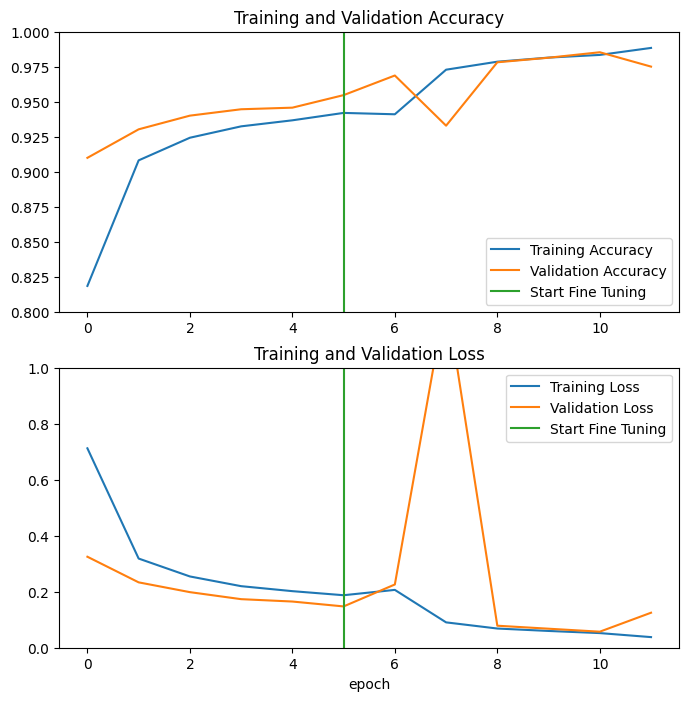

In [41]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [42]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

193/193 ━━━━━━━━━━━━━━━━━━━━ 28s 142ms/step - accuracy: 0.9781 - loss: 0.0992
Test accuracy : 0.9781128168106079


Predictions:
 [34 35 36 31 29 25 14 19  3  3 29 25 25 13  6 10 13 14 26  1 29 36  7 21
  4 34  1 19  2 17 29 38]
Labels:
 [34 35 36 31 30 25 14 19  3  3 29 25 25 13  6 10 13 14 26  1 29 36  7 21
  4 34  1 19  2 17 29 38]


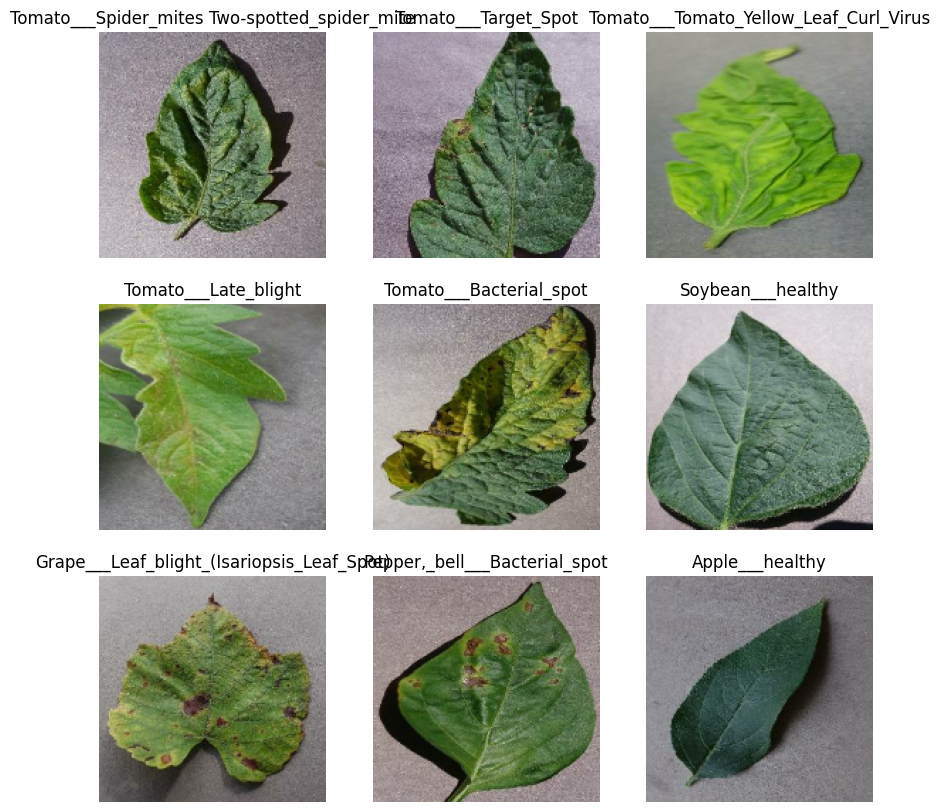

In [43]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch)
predictions = tf.argmax(predictions,axis=1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [45]:
model.save("plant_disease_recog_model_pwp.keras")
model.save("/content/drive/MyDrive/Internship/Task04/plant_disease_recog_model_pwp.keras")